<a href="https://colab.research.google.com/github/Jaaaacklyn/Jaaaacklyn/blob/main/Phylogenetics_BINF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phylogenetics**

In 2022, the H5N1 HPAI Avian influenza strain, 2.3.4.4b, made its first known appearance in North America, likely introduced by migratory birds. Understanding the evolutionary relationships between different strains of H5N1 across the globe can provide insights into how the virus spreads, and how different strains are related to one another.

In this Notebook, we will carry out some important and necessary steps to be able to reconstruct a phylogenetic hypothesis about this pandemic pathogen. To do this, we will perform phylogenetic inference using the maximum likelihood method. This will involve:
* Alignment of genomic sequence data;
* Choose the best nucleotide substitution model;
* Generate a phylogenetic tree;
* Generate a time tree;
* Visulise the tree.



## Required programs or packages

* **MAFFT** for genome alignment (https://mafft.cbrc.jp/alignment/software/)

* **Seqkit** a toolkit for FASTA/Q file manipulation (https://bioinf.shenwei.me/seqkit)

* **IQ-TREE** for reconstruction of the maximum likelihood phylogenetic tree (http://www.iqtree.org/)

* **ggtree** an R package for visualization and annotation of phylogenetic trees with their covariates and other associated data (https://github.com/YuLab-SMU/ggtree)

* **treetime** Maximum likelihood inference of time stamped phylogenies and ancestral reconstruction (https://github.com/neherlab/treetime)




## Other interesting programs


* **Figtree** a Java program to visualize phylogenetic trees (http://tree.bio.ed.ac.uk/software/figtree/).
* **auspice.us** allows interactive exploration of phylogenomic datasets by simply dragging & dropping them onto this page.
* **Clockor2** is a client-side web application for conducting root-to-tip regression



Let's first check the Python version

In [ ]:
!python --version

Python 3.12.11


Installing conda/mamba

In [ ]:
!pip install -q condacolab alv phylo-treetime matplotlib-inline

#Python code to run the installation
import condacolab
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [phylo-treetime]
✨🍰✨ Everything looks OK!


In [ ]:
#Installing software environments
!mamba install --quiet -c bioconda mafft iqtree seqkit

## Downloading the dataset to be analyzed.

We will use a AIV dataset for this practical. This dataset was


In [ ]:
!wget -O AIV_HA.fasta https://raw.githubusercontent.com/Wytamma/BINF90004/main/data/AIV_HA.fasta

--2025-09-11 06:24:42--  https://raw.githubusercontent.com/Wytamma/BINF90004/main/data/AIV_HA.fasta
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874671 (854K) [text/plain]
Saving to: ‘AIV_HA.fasta’

AIV_HA.fasta        100%[===================>] 854.17K  --.-KB/s    in 0.06s   

2025-09-11 06:24:42 (14.6 MB/s) - ‘AIV_HA.fasta’ saved [874671/874671]



## Fasta file format

The FASTA file format (`.fasta`, `.fa`) is a widely used text-based format for representing nucleotide or peptide sequences in bioinformatics. Each sequence in a FASTA file starts with a header line, beginning with a > character, followed by an identifier (such as a sequence name or accession number) and optionally additional descriptive information. The sequence data follows the header and consists of nucleotide bases (for DNA or RNA) or amino acids (for proteins) represented in a single-letter code. Although the sequence data can be split across multiple lines for readability, this is not required, and many bioinformatics tools can handle sequences on a single line.

In [ ]:
!head AIV_HA.fasta

>A/American_Black_Duck/Connecticut/USDA-005000-001/2022|2.3.4.4b|2022-02-06
AUGGAGAACAUAGUACUACUUCUUGCAAUAGUUAGCCUUGUUAAAAGUGAUCAGAUUUGC
AUUGGUUACCAUGCAAACAAUUCGACAGAGCAAGUUGACACGAUAAUGGAAAAGAACGUC
ACUGUUACACAUGCCCAAGACAUACUGGAAAAAACACACAACGGGAAGCUCUGUGAUCUA
AAUGGGGUGAAGCCUCUGAUUUUAAAGGAUUGUAGUGUAGCUGGAUGGCUCCUCGGAAAC
CCAAUGUGCGACGAAUUCAUCAGAGUGCCGGAAUGGUCCUACAUAGUGGAGCGGGCUAAC
CCAGCUAAUGACCUCUGUUACCCAGGGAGCCUCAAUGACUAUGAAGAACUGAAACACAUG
UUGAGCAGAAUAAAUCAUUUUGAGAAGAUUCUGAUCAUCCCCAAGAGUUCCUGGCCAAAU
CAUGAAACAUCACUAGGGGUGAGCGCAGCUUGUCCAUACCAGGGAGCGCCCUCCUUUUUC
AGAAAUGUGGUGUGGCUUAUCAAAAAGAACGAUGCAUACCCAACAAUAAAGAUAAGCUAC


In [ ]:
# Number of sequences
# What is this command doing?
!grep '>' AIV_HA.fasta | wc -l

484


In [ ]:
# Use seqkit to get stats
!seqkit stats --all AIV_HA.fasta

file          format  type  num_seqs  sum_len  min_len  avg_len  max_len     Q1     Q2     Q3  sum_gap    N50  N50_num  Q20(%)  Q30(%)  AvgQual  GC(%)  sum_n
AIV_HA.fasta  FASTA   RNA        484  830,051      688    1,715    1,776  1,704  1,704  1,751        0  1,704       16       0       0        0  42.04    512


In [ ]:
# Convert to DNA and remove any gaps
!seqkit seq --rna2dna --remove-gaps  AIV_HA.fasta > AIV_HA.dna.fasta && cp AIV_HA.dna.fasta AIV_HA.fasta

### Write a fasta file parser in python

Read bioinformatics file formats is an important and routine task.

Q: How can we generalise this code to work with any input file?

In [ ]:

def read_fasta(input_file):
  sequences = {}
  with open(input_file, "r") as f:
      for line in f:
          if line.startswith(">"):
              header = line.strip()[1:] # Why?
              sequences[header] = ""
          else:
              sequences[header] += line.strip()

  return sequences

sequences = read_fasta("AIV_HA.fasta")

print("Number of sequences: ", len(sequences))
print("Min length ", min(len(seq) for seq in sequences.values()))
print("Max length ", max(len(seq) for seq in sequences.values()))
print("Average length ", sum(len(seq) for seq in sequences.values())/len(sequences))

Number of sequences:  484
Min length  688
Max length  1776
Average length  1714.9814049586778


### Filter low quality sequences

We will filter out any sequence with > %10 ambiguous nucleotides (W, S, K, M, Y, R, V, H, D, B, or N).


Q: How can we modify this code to also print any seq with an ambiguous base?

In [ ]:
from collections import Counter

with open("sequence_to_filter.txt", "w") as f:
  for header, sequence in sequences.items():
      non_ambiguous_count = sum(sequence.count(char) for char in "ACTG")
      count = len(sequence) - non_ambiguous_count # ambiguous_count
      # Sequences with > 10% ambiguous nucleotides
      if count > 1:
          print(f"{header}: {count} ambiguous nucleotides")
      if count / len(sequence) > 0.1:
          print(f"Removing {header}: {count} ambiguous nucleotides")
          f.write(header + "\n")

# Filter selected sequences
!seqkit grep -v -f sequence_to_filter.txt AIV_HA.fasta > AIV_HA.filtered.fasta && cp AIV_HA.filtered.fasta AIV_HA.fasta

A/Est/Parnu/eagle/TA21-11864-1/2021|2.3.4.4b|2021-05-16: 2 ambiguous nucleotides
A/chicken/Germany-BB/AI06242/2021|2.3.4.4b|2021-11-02: 2 ambiguous nucleotides
A/great_skua/Scotland/042505/2021|2.3.4.4b|2021-07-22: 2 ambiguous nucleotides
A/herring_gull/Germany-SH/AI06141/2021|2.3.4.4b|2021-10-21: 2 ambiguous nucleotides
A/snow_goose/Kansas/W22-199A/2022|2.3.4.4b|2022-03-14: 509 ambiguous nucleotides
Removing A/snow_goose/Kansas/W22-199A/2022|2.3.4.4b|2022-03-14: 509 ambiguous nucleotides
[INFO] 1 patterns loaded from file


## Alignment

Multiple Sequence Alignment (MSA) is a computational technique used to align three or more biological sequences, typically DNA, RNA, or protein sequences. The goal of MSA is to identify regions of similarity that may indicate functional, structural, or evolutionary relationships among the sequences. MSA is a fundamental method in bioinformatics and is widely used in various applications, such as phylogenetics, protein structure prediction, and functional annotation.

#### MAFFT (Multiple Alignment using Fast Fourier Transform)

We will use MAFFT for sequence alignment. It is quite fast and accurate.

There are many options for aligning sequences using MAFFT. --auto is a good option where the program itself chooses the most efficient algorithm (good balance between speed and accuracy). Alignment can take days for datasets with very long sequences if you have chosen the most accurate algorithm. If you are aligning short sequences, such as a less conserved gene, you can use more computationally expensive but also more accurate options. MAFFT has good examples of what to use and when to use it on its website: https://mafft.cbrc.jp/alignment/software/algorithms/algorithms.html.

* Tip: When you are working with alignments containing hundreds or thousands of sequences from the same virus, mafft can be used to quickly align new sequences to an existing alignment using mafft --add. This parameter and its variations allow aligning complete genomes as well as fragments ([see documentation here](https://mafft.cbrc.jp/alignment/software/addsequences.html))

In [ ]:
!mafft --help

------------------------------------------------------------------------------
  MAFFT v7.525 (2024/Mar/13)
  https://mafft.cbrc.jp/alignment/software/
  MBE 30:772-780 (2013), NAR 30:3059-3066 (2002)
------------------------------------------------------------------------------
High speed:
  % mafft in > out
  % mafft --retree 1 in > out (fast)

High accuracy (for <~200 sequences x <~2,000 aa/nt):
  % mafft --maxiterate 1000 --localpair  in > out (% linsi in > out is also ok)
  % mafft --maxiterate 1000 --genafpair  in > out (% einsi in > out)
  % mafft --maxiterate 1000 --globalpair in > out (% ginsi in > out)

If unsure which option to use:
  % mafft --auto in > out

--op # :         Gap opening penalty, default: 1.53
--ep # :         Offset (works like gap extension penalty), default: 0.0
--maxiterate # : Maximum number of iterative refinement, default: 0
--clustalout :   Output: clustal format, default: fasta
--reorder :      Outorder: aligned, default: input order
--quiet :      

In [ ]:
!mafft --thread -1 --auto AIV_HA.fasta > AIV_HA.aligned.fasta && cp AIV_HA.aligned.fasta AIV_HA.aln

OS = linux
The number of physical cores =  1
nthread = 1
nthreadpair = 1
nthreadtb = 1
ppenalty_ex = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..

There are 18 ambiguous characters.
  401 / 483 (thread    0)
done.

Constructing a UPGMA tree (efffree=0) ... 
  480 / 483
done.

Progressive alignment 1/2... 
STEP   482 / 482 (thread    0) f
done.

Making a distance matrix from msa.. 
  400 / 483 (thread    0)
done.

Constructing a UPGMA tree (efffree=1) ... 
  480 / 483
done.

Progressive alignment 2/2... 
STEP   482 / 482 (thread    0) f
done.

disttbfast (nuc) Version 7.525
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
1 thread(s)

distout=h
generating a scoring matrix for nucleotide (dist=200) ... done
  400 / 483 (thread    0)dndpre (nuc) Version 7.525
alg=X, model=DNA200 (2), 1.53 (4.59), 0.37 (1.11), noshift, amax=0.0
1 thread(s)

minimumweight = 0.000

#### MAFFT OUTPUT

### Key Sections:

- **Threads**: Alignment was run on a single thread (`nthread = 1`).
- **Scoring Matrix**: A matrix was generated for nucleotide sequences with a gap opening penalty of `-1.53`.
- **Distance Matrix & UPGMA Tree**: Calculated pairwise distances and constructed a guide tree for alignment.
- **Progressive Alignment**: Performed in two steps, refining the alignment progressively.
- **Iterative Refinement**: Segments were refined until they converged, indicating a successful alignment.

### Strategy:
- **FFT-NS-i**: Fast alignment with iterative refinement (2 iterations).

In [ ]:
!head AIV_HA.aln

>A/American_Black_Duck/Connecticut/USDA-005000-001/2022|2.3.4.4b|2022-02-06
----------------------------atggagaacatagtactacttcttgcaatagt
tagccttgttaaaagtgatcagatttgcattggttaccatgcaaacaattcgacagagca
agttgacacgataatggaaaagaacgtcactgttacacatgcccaagacatactggaaaa
aacacacaacgggaagctctgtgatctaaatggggtgaagcctctgattttaaaggattg
tagtgtagctggatggctcctcggaaacccaatgtgcgacgaattcatcagagtgccgga
atggtcctacatagtggagcgggctaacccagctaatgacctctgttacccagggagcct
caatgactatgaagaactgaaacacatgttgagcagaataaatcattttgagaagattct
gatcatccccaagagttcctggccaaatcatgaaacatcactaggggtgagcg-----ca
gcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttatcaaaaag


In [ ]:
!seqkit stats AIV_HA.aln

file        format  type  num_seqs    sum_len  min_len  avg_len  max_len
AIV_HA.aln  FASTA   DNA        483  1,021,062    2,114    2,114    2,114


### Inspecting the alignment

The complete sequence of a hemagglutinin (HA) gene of a recent human influenza A strain, A/Victoria/3/75, is 1768 nucleotides long and contains the information for 567 amino acids. Clearly there is something wrong with our a alignment at is it 2114 nucleotides long. We will inspect the alignment to see if we can tell what's wrong.

In [ ]:
#Calling help to know more about the parameters
!alv -h

usage: alv [-h] [--version] [-ai ALIGNMENT_INDEX]
           [-f {guess,fasta,clustal,nexus,phylip,stockholm}]
           [-t {aa,dna,rna,codon,guess}] [-g]
           [-c {clustal,taylor,hydrophobicity}]
           [--code {1,2,3,4,5,6,9,10,11,12,13,14,16,21,22,23,24,25,26,27,28,29,30,31}]
           [-d] [-lc] [-w WIDTH] [-k] [-l] [-i] [-j] [--cite] [--method]
           [-r N] [-s {infile,alpha}] [-si ACCESSION] [-so ACCESSIONS]
           [-sm ACCESSION_PATTERN] [-sa INT INT] [--majority] [--no-indels]
           [--only-variable] [--only-variable-excluding-indels] [-as INT INT]
           [-aa N]
           [infile]

positional arguments:
  infile                The infile is the path to a file, or '-' if reading
                        from stdin.

options:
  -h, --help            show this help message and exit
  --version             show program's version number and exit
  -ai ALIGNMENT_INDEX, --alignment-index ALIGNMENT_INDEX
                        If reading file with many 

In [ ]:
# Run alv to shown the start of the alignment
!alv -sa 0 100 -as 0 20 -w 1000 AIV_HA.aln

A/American_Black_Duc ----------------------------atggagaacatagtactacttcttgcaatagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Black_Duc ----------------------------atggagaacatagtactacttcttgcaatagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Black_Duc ----------------------------atggagaacatagtactacttcttgcaatagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Black_Duc ----------------------------atggagaacatagtactacttcttgcaatagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Black_Duc ----------------------------atggagaacatagtactacttcttgcaatagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Black_Duc ----------------------------atggagaacatagtactacttcttgcaatagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Crow/NB/F ----------------------------atggagaacatagtactacttcttgcaacagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Crow/NB/F ----------------------------atggagaacatagtactacttcttgcaacagttagccttgttaaaagtgatcagatttgcattggttaccat
A/American_Crow/NB/F ---

In [ ]:
# Run alv to shown the end of the alignment
!alv -sa 2000 2114 -as 0 20 -w 1000 AIV_HA.aln

A/American_Black_Duc cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Black_Duc cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Black_Duc cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Black_Duc cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Black_Duc cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Black_Duc cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Crow/NB/F cagaatttgcatttag--------------------------------------------------------------------------------------------------
A/American_Crow/NB/F cagaatttgcatttag-----------

### Filter and trim the aligment

Trim the ends of the aligment (error prone) using the first sequence as a guide.

In [ ]:
!seqkit head -n 1 AIV_HA.aln | seqkit locate -Pdip '(N)' | head -n2 # find the first base i.e. not a gap
!seqkit head -n 1 AIV_HA.aln | seqkit locate -Pdip '(N)' | tail -n1 # find the last base i.e. not a gap

seqID	patternName	pattern	strand	start	end	matched
A/American_Black_Duck/Connecticut/USDA-005000-001/2022|2.3.4.4b|2022-02-06	(N)	(N)	+	29	29	a
A/American_Black_Duck/Connecticut/USDA-005000-001/2022|2.3.4.4b|2022-02-06	(N)	(N)	+	2016	2016	g


In [ ]:
# Colab/python magic to get ends of the aligment
start, *_ = !seqkit head -n 1 AIV_HA.aln | seqkit locate -Pdip '(N)' | sed -n '2p' | awk '{print $5}'
end, *_ = !seqkit head -n 1 AIV_HA.aln | seqkit locate -Pdip '(N)' | sed -n '$p' | awk '{print $5}'

# Trim the aligment
!seqkit -w 0 subseq -r $start:$end AIV_HA.aln > AIV_HA.trimmed.aln && cp AIV_HA.trimmed.aln AIV_HA.aln

[INFO] create or read FASTA index ...
[INFO] create FASTA index for AIV_HA.aln
[INFO]   483 records loaded from AIV_HA.aln.seqkit.fai


To filter poorly aligned sequences we can visually inspect the aligment to find poorly aligned sequences.

Alternatively use the first sequence as a reference and remove any sequences that are significantly different. The code below does this use [Biopython](https://biopython.org/).

In [ ]:
from Bio import AlignIO
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

# Load the MSA file
alignment = AlignIO.read("AIV_HA.aln", "fasta")

# Select the first sequence as the reference
reference_seq = alignment[0].seq

# Define a similarity threshold (e.g., 0.9 = 90%)
threshold = 0.6

def calculate_similarity(seq1, seq2):
    """Calculate the similarity score between two sequences."""
    matches = sum(res1 == res2 for res1, res2 in zip(seq1, seq2))
    return matches / len(seq1)

# Filter sequences
filtered_sequences = []
for record in alignment:
    similarity = calculate_similarity(reference_seq, record.seq)
    if similarity >= threshold:
        filtered_sequences.append(record)
    else:
        print(f"Removing sequence {record.id} with similarity {similarity:.2f}")

# Save the filtered sequences to a new FASTA file
with open("AIV_HA.clean.aln", "w") as output_handle:
    SeqIO.write(filtered_sequences, output_handle, "fasta")

Removing sequence A/buzzard/Germany-NI/AI04429/2021|2.3.4.4b|2021-04-28 with similarity 0.47
Removing sequence A/royal_tern/Florida/W22-245A/2022|2.3.4.4b|2022-03-02 with similarity 0.33
Removing sequence A/teal/Samara/Bolshechernigovsky/2021|2.3.4.4b|2021-10-13 with similarity 0.49
Removing sequence A/white-tailed_sea_eagle/Germany-MV/2022AI04824/2021|2.3.4.4b|2021-11-26 with similarity 0.47


In [ ]:
!seqkit stats AIV_HA.clean.aln

file              format  type  num_seqs  sum_len  min_len  avg_len  max_len
AIV_HA.clean.aln  FASTA   DNA        479  952,252    1,988    1,988    1,988


### Realign

As we have removed several samples we should realign our sequences.

In [ ]:
!mafft --thread -1 --auto AIV_HA.clean.aln > AIV_HA.realigned.aln && cp AIV_HA.realigned.aln AIV_HA.aln

OS = linux
The number of physical cores =  1
nthread = 1
nthreadpair = 1
nthreadtb = 1
ppenalty_ex = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..

There are 16 ambiguous characters.
  401 / 479 (thread    0)
done.

Constructing a UPGMA tree (efffree=0) ... 
  470 / 479
done.

Progressive alignment 1/2... 
STEP   478 / 478 (thread    0) f
done.

Making a distance matrix from msa.. 
  400 / 479 (thread    0)
done.

Constructing a UPGMA tree (efffree=1) ... 
  470 / 479
done.

Progressive alignment 2/2... 
STEP   478 / 478 (thread    0) f
done.

disttbfast (nuc) Version 7.525
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
1 thread(s)

distout=h
generating a scoring matrix for nucleotide (dist=200) ... done
  400 / 479 (thread    0)dndpre (nuc) Version 7.525
alg=X, model=DNA200 (2), 1.53 (4.59), 0.37 (1.11), noshift, amax=0.0
1 thread(s)

minimumweight = 0.000

In [ ]:
!seqkit stats --all AIV_HA.aln

file        format  type  num_seqs  sum_len  min_len  avg_len  max_len     Q1     Q2     Q3  sum_gap    N50  N50_num  Q20(%)  Q30(%)  AvgQual  GC(%)  sum_n
AIV_HA.aln  FASTA   DNA        479  816,216    1,704    1,704    1,704  1,704  1,704  1,704      177  1,704        1       0       0        0  42.11      3


Q: Can you identify columns with transitions (A<->G,T<->C) or transversions? Which is more common?  
Q: What is interesting about site 398?

In [ ]:
!alv -sa 398 500 -as 0 20 -w 200 AIV_HA.aln

A/American_Black_Duc ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcagcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Black_Duc ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcagcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Black_Duc ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcagcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Black_Duc ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcagcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Black_Duc ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcagcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Black_Duc ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcagcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Crow/NB/F ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcggcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/American_Crow/NB/F ccccaagagttcctggccaaatcatgaaacatcactaggggtgagcgcggcttgtccataccagggagcgccctcctttttcagaaatgtggtgtggcttat
A/Americ

## Phylogenetic Inference

IQ-TREE allows you to perform maximum likelihood phylogenetic analyzes of hundreds or thousands of sequences. With it you can:

* **Estimate the evolutionary model:** has an integrated program called ModeFinder, which quickly evaluates a large number of nucleotide substitution models and chooses the most suitable one for the data set in question.
* **Infer maximum likelihood tree:** estimates and evaluates the robustness of the best tree using approaches such as bootstrap, ultra-fast bootstrap or probabilistic evaluations.

The program can also be run on online servers:
* W-IQ-TREE Server – http://iqtree.cibiv.univie.ac.at/
* Cyberinfrastructure for Phylogenetic Research (CIPRES) – https://www.phylo.org/
* HIV Sequence Database – https://www.hiv.lanl.gov/content/sequence/IQTREE/iqtree.html

In [ ]:
!iqtree -h

IQ-TREE version 3.0.1 for Linux x86 64-bit built Jul  9 2025
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Usage: iqtree [-s ALIGNMENT] [-p PARTITION] [-m MODEL] [-t TREE] ...

GENERAL OPTIONS:
  -h, --help           Print (more) help usages
  -s FILE[,...,FILE]   PHYLIP/FASTA/NEXUS/CLUSTAL/MSF alignment file(s)
  -s DIR               Directory of alignment files
  --seqtype STRING     BIN, DNA, AA, NT2AA, CODON, MORPH (default: auto-detect)
  -t FILE|PARS|RAND    Starting tree (default: 99 parsimony and BIONJ)
  -o TAX[,...,TAX]     Outgroup taxon (list) for writing .treefile
  --prefix STRING      Prefix for all output files (default: aln/partition)
  --seed NUM           Random seed number, normally used for debugging purpose
  --safe               Safe likelihood kernel to avoid numerical underflow
  --mem NUM[G|M|%]     Maximal RAM

In [ ]:
!iqtree -s AIV_HA.aln -m TEST -B 1000

#Parameters
# -s: alignment file name
# -m: model selection strategy. If no option is specified
# -B: method to assess clade support, number of replicas for ultra-fast bootstrap - results can be retrieved in .treefile and .contree

IQ-TREE version 3.0.1 for Linux x86 64-bit built Jul  9 2025
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    c4675c7ab90d (AVX2, FMA3, 12 GB RAM)
Command: iqtree -s AIV_HA.aln -m TEST -B 1000
Seed:    811171 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Thu Sep 11 06:37:53 2025
Kernel:  AVX+FMA - 1 threads (2 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 2 cores!
HINT: -nt AUTO will automatically determine the best number of threads to use.

Reading alignment file AIV_HA.aln ... Fasta format detected
Reading fasta file: done in 0.0139347 secs using 88.23% CPU
Alignment most likely contains DNA/RNA sequences
Constructing alignment: done in 0.00668891 secs using 99.06% CPU
Alignment has 479 sequences with 1704 columns, 341 distinct patterns
185 parsimony-informative

When the process is complete, output files will be found in the folder, including:

* **AIV_HA.aln.treefile:** the ML tree in NEWICK format, which can be viewed by any tree visualization program that supports the NEWICK format
* **AIV_HA.aln.contree:** the consensus ML tree obtained by fastbootstrap in NEWICK format, which can be viewed by any supported tree visualization program.
* **AIV_HA.aln.iqtree:** the main analysis report file. It also contains a textual representation of the final tree
* **AIV_HA.aln.log:** log file of the entire execution (the same as what is displayed on the screen).

Q: What DNA model was selected for by ModelFinder?

In [ ]:
#Viewing trees in newick format
!cat AIV_HA.aln.iqtree

IQ-TREE 3.0.1 built Jul  9 2025

Input file name: AIV_HA.aln
Type of analysis: ModelFinder + tree reconstruction + ultrafast bootstrap (1000 replicates)
Random seed number: 811171

REFERENCES
----------

To cite IQ-TREE 3 please use:

Thomas K.F. Wong, Nhan Ly-Trong, Huaiyan Ren, Hector Banos, Andrew J. Roger,
Edward Susko, Chris Bielow, Nicola De Maio, Nick Goldman, Matthew W. Hahn,
Gavin Huttley, Robert Lanfear, Bui Quang Minh (2025)
IQ-TREE 3: Phylogenomic Inference Software using Complex Evolutionary Models.
Submitted.

Please also cite the following paper(s) for the feature(s) that you used:

To cite ModelFinder please use: 

Subha Kalyaanamoorthy, Bui Quang Minh, Thomas KF Wong, Arndt von Haeseler,
and Lars S Jermiin (2017) ModelFinder: Fast model selection for
accurate phylogenetic estimates. Nature Methods, 14:587–589.
https://doi.org/10.1038/nmeth.4285

Since you used ultrafast bootstrap (UFBoot) please also cite: 

Diep Thi Hoang, Olga Chernomor, Arndt von Haeseler, Bui Quang

In [ ]:
#Viewing trees in newick format
!cat AIV_HA.aln.treefile

(A/American_Black_Duck/Connecticut/USDA-005000-001/2022|2.3.4.4b|2022-02-06:0.0017673299,((((((((((((((((((((((((((A/American_Black_Duck/Connecticut/USDA-005313-006/2022|2.3.4.4b|2022-02-16:0.0005873140,A/American_Black_Duck/Connecticut/USDA-005313-007/2022|2.3.4.4b|2022-02-16:0.0005873140)78:0.0000010000,A/American_Black_Duck/Connecticut/USDA-005313-008/2022|2.3.4.4b|2022-02-16:0.0011755486)100:0.0005873140,A/american_crow/Massachusetts/22-006976-004/2022|2.3.4.4b|2022-02-27:0.0011737703)4:0.0000010000,((A/Bufflehead/NB/FAV-0130-1/2022|2.3.4.4b|2022-02-08:0.0005873140,A/bald_eagle/Massachusetts/22-006976-001/2022|2.3.4.4b|2022-02-27:0.0000010000)100:0.0005873140,(A/Sanderling/Massachusetts/USDA-007696-001/2022|2.3.4.4b|2022-03-01:0.0000010000,A/sanderling/MA/22HP00124/2022|2.3.4.4b|2022-03-01:0.0000010000)100:0.0011755486)20:0.0000010000)6:0.0000010000,A/American_Crow/NB/FAV-0118-1/2022|2.3.4.4b|2022-02-12:0.0000010000)15:0.0000010000,(((A/American_Crow/NB/FAV-0117-4/2022|2.3.4.4b|202

## Root to tip regression

We can download our tree and use https://clockor2.github.io to create a root-to-tip regression.

Dateformat = YYYY-MM-DD  
Delimiter = |  
Date Location = -1  

In [ ]:
from google.colab import files
files.download("AIV_HA.aln.treefile")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

It looks like `A/glaucous_gull/USA/22-023553-001/1905|2.3.4.4b|1905-07-14` has an incorrect date. Looking on NCBI we can find the correct year `2022` in the metadata (https://www.ncbi.nlm.nih.gov/nuccore/PP801670.1). Let's fix that date with `sed`.

`sed` (stream editor) is a Unix command-line utility used for parsing and transforming text streams or files. It processes text line-by-line, applying operations such as searching, replacing, deleting, inserting, or modifying text. sed is non-interactive, meaning it can automatically edit text without manual intervention, making it efficient for batch processing. The most common usage of sed involves substitution (s/old/new/), but it supports more complex operations using regular expressions. It's often used in shell scripts for automated text processing, such as modifying configuration files or log data on-the-fly.

![image](https://raw.githubusercontent.com/Wytamma/BINF90004/refs/heads/main/data/clockor2.png)

In [ ]:
!sed -h

sed: invalid option -- 'h'
Usage: sed [OPTION]... {script-only-if-no-other-script} [input-file]...

  -n, --quiet, --silent
                 suppress automatic printing of pattern space
      --debug
                 annotate program execution
  -e script, --expression=script
                 add the script to the commands to be executed
  -f script-file, --file=script-file
                 add the contents of script-file to the commands to be executed
  --follow-symlinks
                 follow symlinks when processing in place
  -i[SUFFIX], --in-place[=SUFFIX]
                 edit files in place (makes backup if SUFFIX supplied)
  -l N, --line-length=N
                 specify the desired line-wrap length for the `l' command
  --posix
                 disable all GNU extensions.
  -E, -r, --regexp-extended
                 use extended regular expressions in the script
                 (for portability use POSIX -E).
  -s, --separate
                 consider files as separate rathe

In [ ]:
!sed 's/1905-07-14/2022-02-14/g' AIV_HA.aln > AIV_HA.date.fixed.aln && cp AIV_HA.date.fixed.aln AIV_HA.aln
!sed 's/1905-07-14/2022-02-14/g' AIV_HA.aln.treefile > AIV_HA.date.fixed.treefile && cp AIV_HA.date.fixed.treefile AIV_HA.aln.treefile

## Creating a Time Tree (Chronogram)

We can use [TreeTime](https://treetime.readthedocs.io/en/latest/) to create a Time Tree.

TreeTime provides routines for ancestral sequence reconstruction and inference of molecular-clock phylogenies, i.e., a tree where all branches are scaled such that the positions of terminal nodes correspond to their sampling times and internal nodes are placed at the most likely time of divergence.

To optimize the likelihood of time-scaled phylogenies, TreeTime uses an iterative approach that first optimizes branch lengths of the tree given the sequence data and date constraints, and then optimizes coalescent tree priors, relaxed clock parameters, or resolves polytomies. This cycle is repeated a few times.

To run treetime we need a csv file that links tip labels to dates. We can generate this file from the tip labels.

In [ ]:
with open("AIV_HA.metadata", "w") as f:
  f.write("name,date\n")
  for line in open("AIV_HA.aln"):
    if not line.startswith(">"):
      continue
    header = line.strip()[1:]
    f.write(f"{header},{header.split('|')[-1]}\n")

In [ ]:
!treetime --tree AIV_HA.aln.treefile --dates AIV_HA.metadata --aln AIV_HA.aln --outdir timetree


Attempting to parse dates...
	Using column 'name' as name. This needs match the taxon names in the tree!!
	Using column 'date' as date.

0.00	-TreeAnc: set-up

10.77	TreeTime.reroot: with method or node: least-squares

10.77	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

12.51	TreeTime.reroot: with method or node: least-squares

12.51	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

15.57	###TreeTime.run: INITIAL ROUND

23.42	TreeTime.reroot: with method or node: least-squares

23.42	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

25.15	###TreeTime.run: rerunning timetree after rerooting

34.43	###TreeTime.run: ITERATION 1 out of 2 iterations

34.43	DEPRECATION WARNING. TreeTime.resolve_polytomies: You are resolving
     	polytomies using the old 'greedy' mode. This is not well suited for large
     	polytomies. Stochastic resolution will become the default in future
     	versions. To switch now, rerun with the f

Try downloading and opening a few of the output files. There are visulisation as well as

tree as
	 timetree/timetree.pdf

--- root-to-tip plot saved to  
	timetree/root_to_tip_regression.pdf

--- alignment including ancestral nodes saved as  
	 timetree/ancestral_sequences.fasta

--- saved divergence times in
	 timetree/dates.tsv

--- tree saved in nexus format as  
	 timetree/timetree.nexus

--- tree saved in auspice json format as  
	 timetree/auspice_tree.json

--- divergence tree saved in nexus format as  
	 timetree/divergence_tree.nexus

--- saved detected outliers as timetree/outliers.tsv

Q: what is the TMRCA? Is it what you expect?

## Tree visuslsation

Here we will use the fantastic tree visulisation library `ggtree` to display our tree. To do this we need to use the R programming language.

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
# Install required R packages

if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager")
    }
if (system.file(package = "ggtree") == '') {
        BiocManager::install("ggtree",quiet = TRUE)
    }
if (system.file(package = "treeio") == '') {
        BiocManager::install("treeio",quiet = TRUE)
    }

install.packages("ggnewscale")

Update all/some/none? [a/s/n]: a


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/BiocManager_1.30.26.tar.gz'
Content type 'application/x-gzip' length 594489 bytes (580 KB)
downloaded 580 KB


The downloaded source packages are in
	‘/tmp/Rtmps4oaMr/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.21 (BiocManager 1.30.26), R 4.5.1 (2025-06-13)
Installing package(s) 'BiocVersion', 'ggtree'
also installing the dependencies ‘gridGraphics’, ‘ggplotify’, ‘patchwork’, ‘lazyeval’, ‘ape’, ‘aplot’, ‘ggfun’, ‘yulab.utils’, ‘tidytree’, ‘treeio’

Old packages: 'dbplyr', 'dtplyr', 'googledrive'
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggnewscale_0.5.2.tar.gz'
Content type 'applic

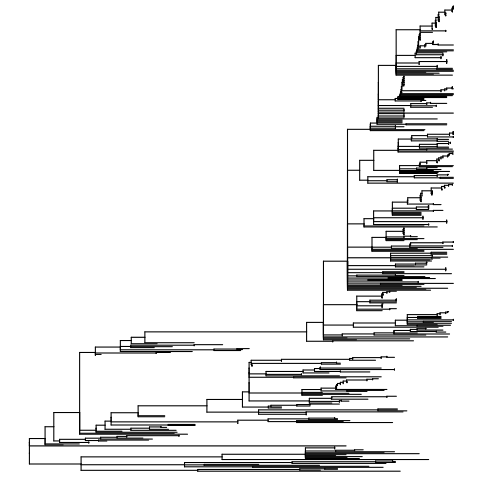

In [ ]:
%%R
library(ggtree)
library(treeio)

tree <- read.nexus("/content/timetree/timetree.nexus")
ggtree(tree)

### What was the date of the introduction into North America?

Use ggtree to visualise the Time to Most Recent Common Ancestor (TMRCA) of the North American clade.

In [ ]:
# Load location mapping file (North America or Other)
!wget -O AIV_HA.country.csv https://raw.githubusercontent.com/Wytamma/BINF90004/main/data/country.csv

--2025-09-11 07:05:30--  https://raw.githubusercontent.com/Wytamma/BINF90004/main/data/country.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38289 (37K) [text/plain]
Saving to: ‘AIV_HA.country.csv’

AIV_HA.country.csv  100%[===================>]  37.39K  --.-KB/s    in 0.01s   

2025-09-11 07:05:30 (3.15 MB/s) - ‘AIV_HA.country.csv’ saved [38289/38289]



In [ ]:
!head AIV_HA.country.csv

name,country,region
A/American_Black_Duck/Connecticut/USDA-005000-001/2022|2.3.4.4b|2022-02-06,USA,North America
A/American_Black_Duck/Connecticut/USDA-005313-006/2022|2.3.4.4b|2022-02-16,USA,North America
A/American_Black_Duck/Connecticut/USDA-005313-007/2022|2.3.4.4b|2022-02-16,USA,North America
A/American_Black_Duck/Connecticut/USDA-005313-008/2022|2.3.4.4b|2022-02-16,USA,North America
A/American_Black_Duck/NL/OTH-0004-14/2021|2.3.4.4b|2021-12-24,Canada,North America
A/American_Black_Duck/NL/OTH-0004-16/2021|2.3.4.4b|2021-12-24,Canada,North America
A/American_Crow/NB/FAV-0117-1/2022|2.3.4.4b|2022-02-12,Canada,North America
A/American_Crow/NB/FAV-0117-4/2022|2.3.4.4b|2022-02-24,Canada,North America
A/American_Crow/NB/FAV-0118-1/2022|2.3.4.4b|2022-02-12,Canada,North America


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.



Attaching package: ‘ape’

The following object is masked from ‘package:treeio’:

    drop.tip

The following object is masked from ‘package:ggtree’:

    rotate


Attaching package: ‘dplyr’

The following object is masked from ‘package:ape’:

    where

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



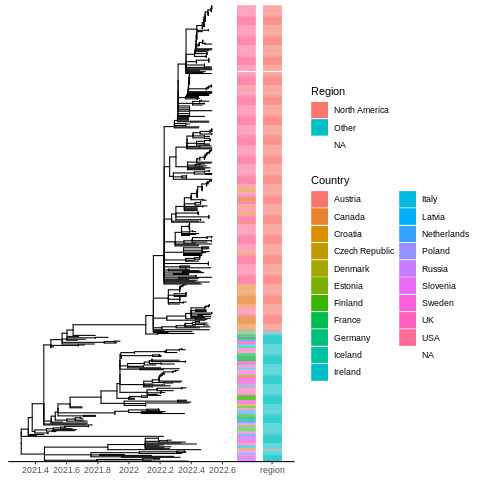

In [ ]:
%%R
# Load libraries
library(ggtree)
library(ape)
library(dplyr)

library(ggnewscale)

# Load the tree and metadata
tree <- read.nexus("/content/timetree/timetree.nexus")
metadata <- read.csv("AIV_HA.country.csv")

# Rename 'name' column in metadata to 'label' to match tree tip labels
metadata <- metadata %>% rename(label = name)

# Create a tree plot
p <- ggtree(tree, mrsd="2022-07-14") +
  theme_tree2()

# Convert metadata to a format suitable for gheatmap (rownames = tip labels)
rownames(metadata) <- metadata$label
metadata <- metadata %>% select(-label)  # Remove label column since it's now rownames

# Create a heatmap next to the tree
p_heatmap <- gheatmap(p, metadata %>% select(country), width = 0.1, offset=.1, colnames = FALSE, colnames_offset_y = .25, legend_title = "Country") +
  scale_x_ggtree() +
  new_scale_fill()


p_heatmap <- gheatmap(p_heatmap, metadata %>% select(region), width = 0.1, offset=.265, colnames = FALSE, colnames_offset_y = .25, legend_title = "Region") +
  scale_x_ggtree()



# Display the plot with heatmap
p_heatmap


#### Tree visulisation

We can also use Auspice to interactively visualise the tree.

Load the time time and location metadata into https://auspice.us (use the timetree/auspice_tree.json file)

### Divergence times confidence intervals

We can generate confidence intervals for our time tree using tree time (this takes longer to run)

https://treetime.readthedocs.io/en/latest/tutorials/timetree.html#confidence-intervals

In [ ]:
!treetime --tree AIV_HA.aln.treefile --dates AIV_HA.metadata --aln AIV_HA.aln --outdir timetree-confidence --confidence --covariation


Attempting to parse dates...
	Using column 'name' as name. This needs match the taxon names in the tree!!
	Using column 'date' as date.

0.00	-TreeAnc: set-up

3.86	TreeTime.reroot: with method or node: least-squares

3.86	TreeTime.reroot: rerooting will ignore covariance and shared ancestry.

5.11	TreeTime.reroot: with method or node: least-squares

5.12	TreeTime.reroot: rerooting will account for covariance and shared ancestry.

9.30	###TreeTime.run: INITIAL ROUND

18.35	TreeTime.reroot: with method or node: least-squares

18.36	TreeTime.reroot: rerooting will account for covariance and shared
     	ancestry.

20.56	###TreeTime.run: rerunning timetree after rerooting

31.19	###TreeTime.run: ITERATION 1 out of 2 iterations

31.19	DEPRECATION WARNING. TreeTime.resolve_polytomies: You are resolving
     	polytomies using the old 'greedy' mode. This is not well suited for large
     	polytomies. Stochastic resolution will become the default in future
     	versions. To switch now, rerun

### Q: What is your estimate for the date and location of introduction of H5N1 into North America?

## Download all output



In [ ]:
!zip -r BINF90004-phylo.zip .

from google.colab import files
files.download("BINF90004-phylo.zip")

  adding: .config/ (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2025.09.09/ (stored 0%)
  adding: .config/logs/2025.09.09/13.45.50.449567.log (deflated 58%)
  adding: .config/logs/2025.09.09/13.45.20.812567.log (deflated 92%)
  adding: .config/logs/2025.09.09/13.46.02.456374.log (deflated 86%)
  adding: .config/logs/2025.09.09/13.46.21.527799.log (deflated 56%)
  adding: .config/logs/2025.09.09/13.46.08.280393.log (deflated 58%)
  adding: .config/logs/2025.09.09/13.46.20.727375.log (deflated 57%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/active_config (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/.last_update_check.json (deflated 22%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/hi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>